# 07 — Event Models, RQ2 Importance, and RQ3 Evaluation (FES v1.1)

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 3.1
Controlled migration 2026-07-14: trains the three approved event-enhanced candidates and the RQ2-only Random Forest importance tool from the validated 92-feature FES v1.1 matrix, compares the candidates with `Baseline_LASSO` v1.1, and retains the dated FES v1.0 outputs as historical evidence.

---

## Purpose

Train the three approved event-enhanced candidates (`model_contract.md`, MCP v1.0) on the full 92-feature FES v1.1 matrix, regenerate the Random Forest/SHAP evidence for RQ2, evaluate each candidate against `Baseline_LASSO` v1.1, and state the current RQ3 verdict.

## Inputs

| File | Role |
|------|------|
| `data/processed/feature_matrix.parquet` | FES v1.1, validation `PASS`, read-only — full 92-feature set |
| `data/processed/feature_profile.json` | Persisted train-split scaling parameters |
| `models/baseline/baseline_lasso.joblib` | Validated `Baseline_LASSO` v1.1 every candidate must beat |
| `models/event/event_model_metadata.json` | Recorded hyperparameters (`best_params`) for XGBoost/LightGBM — see note below |

**On hyperparameters:** `Event_LASSO` repeats its deterministic `LassoCV` alpha-path search. XGBoost and LightGBM use the recorded winning FES v1.0 parameters because the original search spaces were not persisted; inventing new grids would confound the feature-version migration with a new tuning experiment. The fixed-parameter transfer is disclosed in metadata and the decision log. The RQ2 Random Forest uses the previously documented fixed specification (`n_estimators=500`, seed 42) and is not an RQ3 candidate.

## Outputs

| File | Role |
|------|------|
| `models/event/event_lasso.joblib`, `xgboost.joblib`, `lightgbm.joblib` | Trained model objects |
| `reports/model_comparison/model_comparison.parquet` | RMSE/MAE/R²/Dir_Acc/IC, all 4 models × {train, test} |
| `reports/model_comparison/statistical_tests.json` | Diebold-Mariano + two-proportion z-test vs. baseline, Bonferroni verdict |
| `reports/model_comparison/feature_importance.parquet` | Reproducible 92-feature Random Forest ranking for RQ2 |
| `reports/model_comparison/model_evaluation_validation.json` | Hash-bound input, model, SHAP, RF, comparison, and save validation |

**Controlled save rule:** FES v1.0 artefacts are copied to dated archives before execution. Current paths are replaced only after the FES v1.1 input gate, baseline binding, finite-input checks, SHAP reconstruction, RF ranking, and statistical comparison complete successfully.

## Research Questions Supported

**RQ3** (primary) — can event-informed models outperform the market-only baseline? **RQ2** (also direct) — which event, macro, and market features rank most strongly under Random Forest importance, corroborated by held-out SHAP magnitude? Notebook 08 visualises these saved results; it does not train them.

## Pipeline Position

`06_model_training.ipynb` → **`07_model_evaluation.ipynb`** → `08_results_visualisation.ipynb`.

## Scope — this notebook DOES

- Read the validated FES v1.1 matrix's full 92-feature set (not legacy `model_features.parquet`)
- Train `Event_LASSO` (fresh `LassoCV` search), `XGBoost`/`LightGBM` (refit from recorded `best_params`)
- Compute the full point-estimate metric suite (RMSE, MAE, R², Dir. Acc., IC, confusion matrix, ROC-AUC) for all four models
- Compute the Diebold-Mariano test and two-proportion z-test of each event-enhanced model vs. `Baseline_LASSO`, Bonferroni-corrected (α = 0.0167)
- State the RQ3 verdict explicitly: supported, partially supported, or not supported
- Regenerate the fixed 500-tree Random Forest importance ranking and three held-out SHAP matrices
- Compare the current result descriptively with the dated FES v1.0 archive; changes are reported, not forced to match

## Scope — this notebook does NOT

- Use `model_features.parquet` (legacy, superseded) anywhere
- Re-run `RandomizedSearchCV` for XGBoost/LightGBM (would not reproduce the frozen hyperparameters — see note above)
- Introduce a new hyperparameter search space or change the frozen promotion rule
- Treat Random Forest as a fourth RQ3 candidate; it remains an RQ2-only descriptive ranking tool
- Modify `feature_matrix.parquet`, `Baseline_LASSO`, or any other frozen artefact

**Target:** `fwd_return_1d`, identical across all four models.

In [18]:
import warnings, json, hashlib, platform, sys
from importlib.metadata import version as package_version
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import lightgbm as lgb
import joblib

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
PROC = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
REPORTS = ROOT / 'reports'
(MODELS / 'event').mkdir(parents=True, exist_ok=True)
(REPORTS / 'model_comparison').mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
ALPHA_BONFERRONI = 0.05 / 3  # 3-model family (Event_LASSO, XGBoost, LightGBM), statistical_decision_matrix.md Part K
print(f'Bonferroni-corrected alpha: {ALPHA_BONFERRONI}')

Bonferroni-corrected alpha: 0.016666666666666666


---
## Section 1 — Load `feature_matrix.parquet`, Scaling Parameters, and `Baseline_LASSO`

In [19]:
matrix_path = PROC / 'feature_matrix.parquet'
fm = pd.read_parquet(matrix_path)
profile = json.loads((PROC / 'feature_profile.json').read_text())
fm_validation = json.loads((PROC / 'feature_matrix_validation.json').read_text())
matrix_sha256 = hashlib.sha256(matrix_path.read_bytes()).hexdigest()

ALL_FEATURES = sum(profile['category_membership'].values(), [])
TARGET = 'fwd_return_1d'
assert fm_validation['validation_status'] == 'PASS'
assert fm_validation['fes_version'] == profile['feature_matrix_version'] == '1.1'
assert fm_validation['dataset_version'] == '1.2'
assert fm_validation['feature_count'] == profile['feature_count'] == len(ALL_FEATURES) == 92
assert len(ALL_FEATURES) == len(set(ALL_FEATURES))
assert set(ALL_FEATURES) == set(fm.columns) - {'date', 'split', TARGET}
assert matrix_sha256 == fm_validation['artifact_sha256'] == profile['artifact_sha256']
assert len(fm) == fm_validation['row_count'] == profile['rows'] == 2477
assert not fm_validation.get('constant_columns')
assert not fm_validation.get('near_zero_variance_columns')

train = fm[fm['split'] == 'train'].reset_index(drop=True)
test = fm[fm['split'] == 'test'].reset_index(drop=True)
assert (len(train), len(test)) == (1727, 750)

scale_params = profile['scaling']['parameters']
assert all(np.isfinite(scale_params[c]['std']) and scale_params[c]['std'] > 0 for c in ALL_FEATURES)
def scale(frame, cols):
    out = frame[cols].copy()
    for c in cols:
        out[c] = (out[c] - scale_params[c]['mean']) / scale_params[c]['std']
    return out

X_train = scale(train, ALL_FEATURES)
X_test = scale(test, ALL_FEATURES)
y_train = train[TARGET].to_numpy()
y_test = test[TARGET].to_numpy()
assert np.isfinite(X_train.to_numpy()).all() and np.isfinite(X_test.to_numpy()).all()
assert np.isfinite(y_train).all() and np.isfinite(y_test).all()

baseline_model_path = MODELS / 'baseline' / 'baseline_lasso.joblib'
baseline_metadata = json.loads((MODELS / 'baseline' / 'baseline_model_metadata.json').read_text())
baseline_validation = json.loads((REPORTS / 'baseline' / 'baseline_model_validation.json').read_text())
assert baseline_metadata['model_version'] == '1.1'
assert baseline_metadata['feature_matrix_version'] == 'FES v1.1'
assert baseline_metadata['input_sha256'] == matrix_sha256
assert baseline_validation['validation_status'] == 'PASS'
assert baseline_validation['feature_matrix_sha256'] == matrix_sha256
baseline_lasso = joblib.load(baseline_model_path)
MARKET_FEATURES = profile['category_membership']['market']
assert baseline_metadata['features'] == MARKET_FEATURES and len(MARKET_FEATURES) == 27
X_train_baseline = scale(train, MARKET_FEATURES)
X_test_baseline = scale(test, MARKET_FEATURES)
pred_train_baseline = baseline_lasso.predict(X_train_baseline)
pred_test_baseline = baseline_lasso.predict(X_test_baseline)
saved_baseline_predictions = pd.read_parquet(REPORTS / 'baseline' / 'baseline_predictions.parquet')
assert np.allclose(saved_baseline_predictions.loc[saved_baseline_predictions['split']=='test', 'predicted'],
                   pred_test_baseline, atol=0, rtol=0)

print(f'FES v1.1 input: PASS · {len(ALL_FEATURES)} features · sha256={matrix_sha256}')
print(f'Train: {X_train.shape}   Test: {X_test.shape}')
print('Baseline_LASSO v1.1 binding: PASS · all-zero coefficients:', np.allclose(baseline_lasso.coef_, 0))

FES v1.1 input: PASS · 92 features · sha256=127a6dbe4b83e59c873dfdf7502060aab115037732bbb723f9d489c6b85dc383
Train: (1727, 92)   Test: (750, 92)
Baseline_LASSO v1.1 binding: PASS · all-zero coefficients: True


---
## Section 2 — Shared Metric Function

In [20]:
def compute_metrics(y_true, y_pred, with_classification=False):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = np.sum((y_true - y_pred) ** 2); ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
    dir_true = np.sign(y_true); dir_pred = np.sign(y_pred)
    dir_acc = float(np.mean(dir_pred == dir_true))
    ic_raw = stats.spearmanr(y_pred, y_true)[0]
    ic = float(ic_raw) if np.isfinite(ic_raw) else None
    out = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Dir_Acc': dir_acc, 'IC': ic}
    if with_classification:
        y_true_bin = (y_true > 0).astype(int)
        y_pred_bin = (y_pred > 0).astype(int)
        tp = int(((y_pred_bin == 1) & (y_true_bin == 1)).sum())
        tn = int(((y_pred_bin == 0) & (y_true_bin == 0)).sum())
        fp = int(((y_pred_bin == 1) & (y_true_bin == 0)).sum())
        fn = int(((y_pred_bin == 0) & (y_true_bin == 1)).sum())
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        try:
            roc_auc = float(roc_auc_score(y_true_bin, y_pred))
        except ValueError:
            roc_auc = float('nan')
        out['confusion_matrix'] = {'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn}
        out['precision'] = precision; out['recall'] = recall; out['f1'] = f1
        out['accuracy'] = (tp + tn) / len(y_true); out['roc_auc'] = roc_auc
    return out

def dm_test(loss_baseline, loss_model):
    """One-sided Diebold-Mariano test: H1 = model beats baseline (lower loss)."""
    d = loss_baseline - loss_model
    n = len(d)
    mean_d = d.mean()
    std_d_pop = d.std(ddof=0)  # population std -- matches the frozen implementation exactly
    if std_d_pop == 0:
        return {'dm_stat': None, 'p_value_one_sided': None,
                'mean_loss_diff': float(mean_d), 'loss_diff_series_std': float(d.std(ddof=1))}
    dm_stat = mean_d / (std_d_pop / np.sqrt(n))
    p_one_sided = 1 - stats.norm.cdf(dm_stat)
    return {'dm_stat': float(dm_stat), 'p_value_one_sided': float(p_one_sided),
            'mean_loss_diff': float(mean_d), 'loss_diff_series_std': float(d.std(ddof=1))}

def two_proportion_z_test(correct_model, correct_baseline):
    n1, n2 = len(correct_model), len(correct_baseline)
    p1, p2 = correct_model.mean(), correct_baseline.mean()
    p_pool = (correct_model.sum() + correct_baseline.sum()) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se
    # One-sided test of H1: model's directional accuracy > baseline's (p1 > p2).
    # Always 1 - Phi(z) regardless of the sign of z -- a negative z (model worse
    # than baseline) must yield a LARGE p-value (fail to reject), not a small one.
    p_one_sided = 1 - stats.norm.cdf(z)
    return {'z_stat': float(z), 'p_value_one_sided': float(p_one_sided), 'p1': float(p1), 'p2': float(p2),
            'diff_pp': float((p1 - p2) * 100)}

def residual_diagnostics(y_true, y_pred):
    residual = np.asarray(y_true) - np.asarray(y_pred)
    centred = residual - residual.mean(); std0 = centred.std(ddof=0)
    skewness = float(np.mean((centred / std0) ** 3))
    excess_kurtosis = float(np.mean((centred / std0) ** 4) - 3)
    jb = float(len(residual) / 6 * (skewness ** 2 + excess_kurtosis ** 2 / 4))
    dw = float(np.sum(np.diff(residual) ** 2) / np.sum(residual ** 2))
    pred = np.asarray(y_pred)
    het = None if np.ptp(pred) == 0 else float(np.corrcoef(np.abs(residual), pred)[0, 1])
    return {'residual_mean': float(residual.mean()), 'residual_std': float(residual.std(ddof=1)),
            'skewness': skewness, 'excess_kurtosis': excess_kurtosis,
            'durbin_watson': dw, 'jarque_bera_stat': jb,
            'jarque_bera_p': float(np.exp(-jb / 2)), 'het_corr': het}

def empirical_prediction_intervals(y_train_true, y_train_pred):
    residual = np.asarray(y_train_true) - np.asarray(y_train_pred)
    return {'pi_90': {'lower_offset': float(np.quantile(residual, 0.05)),
                      'upper_offset': float(np.quantile(residual, 0.95))},
            'pi_95': {'lower_offset': float(np.quantile(residual, 0.025)),
                      'upper_offset': float(np.quantile(residual, 0.975))},
            'method': 'Empirical residual-quantile, train split only'}

def block_bootstrap_rmse_ci(y_true, y_pred, block_length=21, n_boot=2000, seed=42):
    errors = np.asarray(y_true) - np.asarray(y_pred); n = len(errors)
    rng = np.random.default_rng(seed); values = np.empty(n_boot)
    blocks_needed = int(np.ceil(n / block_length))
    for i in range(n_boot):
        starts = rng.integers(0, n, size=blocks_needed)
        idx = np.concatenate([(np.arange(s, s + block_length) % n) for s in starts])[:n]
        values[i] = np.sqrt(np.mean(errors[idx] ** 2))
    lower, upper = np.quantile(values, [0.025, 0.975])
    return {'rmse_95ci_lower': float(lower), 'rmse_95ci_upper': float(upper),
            'block_length': block_length, 'n_boot': n_boot}

def wilson_interval(successes, n, z=1.959963984540054):
    p = successes / n; denom = 1 + z*z/n
    centre = (p + z*z/(2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / denom
    return {'dir_acc_95ci_lower': float(centre - margin),
            'dir_acc_95ci_upper': float(centre + margin), 'method': 'Wilson score interval'}

print('Metric, diagnostic, interval, DM-test, and z-test functions defined.')

Metric, diagnostic, interval, DM-test, and z-test functions defined.


---
## Section 3 — `Event_LASSO`

Full 92-feature FES v1.1 `LassoCV`, using the same chronological tuning discipline as `Baseline_LASSO`.

In [21]:
event_lasso = LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=RANDOM_SEED, max_iter=50000, tol=1e-6, n_jobs=-1)
event_lasso.fit(X_train, y_train)

pred_train_el = event_lasso.predict(X_train)
pred_test_el = event_lasso.predict(X_test)

print(f'alpha_selected  : {event_lasso.alpha_}')
print(f'n_nonzero_coef  : {int(np.sum(event_lasso.coef_ != 0))} / {len(ALL_FEATURES)}')

metrics_train_el = compute_metrics(y_train, pred_train_el)
metrics_test_el = compute_metrics(y_test, pred_test_el, with_classification=True)
print('train:', metrics_train_el)
print('test :', {k: v for k, v in metrics_test_el.items() if k in ('RMSE','MAE','R2','Dir_Acc','IC')})

alpha_selected  : 0.0018906107300025621
n_nonzero_coef  : 0 / 92
train: {'RMSE': 0.011995288892314613, 'MAE': 0.007536431418438753, 'R2': 0.0, 'Dir_Acc': 0.5477707006369427, 'IC': None}
test : {'RMSE': 0.009631061816812675, 'MAE': 0.006547931743181517, 'R2': -0.0015064059786111805, 'Dir_Acc': 0.5746666666666667, 'IC': None}


---
## Section 4 — `XGBoost`

Refit directly from the recorded `best_params` (see title-cell note on why this notebook does not re-run `RandomizedSearchCV`).

In [22]:
with open(MODELS / 'event' / 'event_model_metadata.json') as f:
    event_meta = json.load(f)

xgb_params = event_meta['models']['XGBoost']['best_params']
tree_parameter_source = event_meta.get(
    'source', event_meta['models']['XGBoost'].get(
        'parameter_source', 'Transferred recorded FES v1.0 winning parameters'))
print('XGBoost best_params (recorded, Mission 07):', xgb_params)

xgb_model = xgb.XGBRegressor(**xgb_params, random_state=RANDOM_SEED, n_jobs=-1, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)

pred_train_xgb = xgb_model.predict(X_train)
pred_test_xgb = xgb_model.predict(X_test)

metrics_train_xgb = compute_metrics(y_train, pred_train_xgb)
metrics_test_xgb = compute_metrics(y_test, pred_test_xgb, with_classification=True)
print('train:', metrics_train_xgb)
print('test :', {k: v for k, v in metrics_test_xgb.items() if k in ('RMSE','MAE','R2','Dir_Acc','IC')})

XGBoost best_params (recorded, Mission 07): {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.5, 'min_child_weight': 3, 'reg_alpha': 0.5, 'reg_lambda': 0.5}
train: {'RMSE': 0.010577103385616989, 'MAE': 0.006794695267709947, 'R2': 0.22247909439965918, 'Dir_Acc': 0.6554719166184134, 'IC': 0.4992350842448194}
test : {'RMSE': 0.00965606312396423, 'MAE': 0.006631869201756855, 'R2': -0.006712782829070507, 'Dir_Acc': 0.48933333333333334, 'IC': 0.024945595102119546}


---
## Section 5 — `LightGBM`

Refit directly from the recorded `best_params`, same rationale as XGBoost above.

In [23]:
lgb_params = event_meta['models']['LightGBM']['best_params']
print('LightGBM best_params (recorded, Mission 07):', lgb_params)

lgb_model = lgb.LGBMRegressor(**lgb_params, random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train)

pred_train_lgb = lgb_model.predict(X_train)
pred_test_lgb = lgb_model.predict(X_test)

metrics_train_lgb = compute_metrics(y_train, pred_train_lgb)
metrics_test_lgb = compute_metrics(y_test, pred_test_lgb, with_classification=True)
print('train:', metrics_train_lgb)
print('test :', {k: v for k, v in metrics_test_lgb.items() if k in ('RMSE','MAE','R2','Dir_Acc','IC')})

LightGBM best_params (recorded, Mission 07): {'n_estimators': 200, 'num_leaves': 15, 'max_depth': 4, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.7, 'min_child_samples': 30, 'reg_alpha': 0.0, 'reg_lambda': 1.5}
train: {'RMSE': 0.011036535681906162, 'MAE': 0.0071742186961234805, 'R2': 0.15346655753796845, 'Dir_Acc': 0.5946728430804864, 'IC': 0.3090460781352018}
test : {'RMSE': 0.009699663070002773, 'MAE': 0.006769780479736723, 'R2': -0.015824512205936392, 'Dir_Acc': 0.44266666666666665, 'IC': -0.05058046657622094}


**Interpretation.** The FES v1.1 train/test gaps below must be interpreted from the current execution rather than copied from FES v1.0. Any continuing XGBoost overfitting pattern remains a limitation; any material change is recorded as a migration result, not normalised away.

---
## Section 5B — Predictions, SHAP, and Reproducible RQ2 Random Forest Importance

This section regenerates the prediction and held-out SHAP artefacts consumed by Notebook 08. XGBoost/LightGBM use their native exact contribution APIs and Event_LASSO uses the closed-form linear identity, avoiding the external `shap`/Numba dependency. Each SHAP matrix must reconstruct its model's predictions.

It also closes limitation L15 by restoring the documented RQ2-only Random Forest step: `RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)` fits once on the FES v1.1 training split and produces a complete 92-row impurity-importance ranking. The >0.001 flag is descriptive and does not alter FES v1.1 or make Random Forest an RQ3 candidate.


In [24]:
# ── Full-sample predictions for all four models (train + test) ────────────────
X_full = scale(fm, ALL_FEATURES)
X_full_baseline = scale(fm, MARKET_FEATURES)

event_model_predictions = pd.DataFrame({
    'date': fm['date'].values,
    'split': fm['split'].values,
    'actual': fm[TARGET].values,
    'Baseline_LASSO_pred': baseline_lasso.predict(X_full_baseline),
    'Event_LASSO_pred': event_lasso.predict(X_full),
    'XGBoost_pred': xgb_model.predict(X_full),
    'LightGBM_pred': lgb_model.predict(X_full),
})
print(f'event_model_predictions: {event_model_predictions.shape}')
print(event_model_predictions.head(3).to_string(index=False))

event_model_predictions: (2477, 7)
      date split    actual  Baseline_LASSO_pred  Event_LASSO_pred  XGBoost_pred  LightGBM_pred
2016-02-24 train  0.012039             0.000466          0.000466      0.004405       0.002164
2016-02-25 train -0.002304             0.000466          0.000466     -0.000212       0.000710
2016-02-26 train -0.007873             0.000466          0.000466      0.002322       0.000899


In [25]:
# ── SHAP values on the test split, one dataframe per event-enhanced model ─────
# Method matches models/archive/pre_2026-07-13_pipeline_rebuild/reports_statistics/07_event_models_summary.md exactly: XGBoost/LightGBM's
# own built-in per-prediction contribution APIs, and the closed-form linear SHAP identity
# for Event_LASSO. Each is verified below to reconstruct model.predict(X_test) exactly.
import xgboost as _xgb

# Event_LASSO: for a linear model on standardized features, SHAP_i = coef_i * x_scaled_i
# exactly, and base_value = intercept (constant across rows) -- verified by reconstruction.
shap_event_lasso = X_test[ALL_FEATURES].copy()
for i, feat in enumerate(ALL_FEATURES):
    shap_event_lasso[feat] = event_lasso.coef_[i] * X_test[feat].values
shap_event_lasso['base_value'] = event_lasso.intercept_
_recon_el = shap_event_lasso[ALL_FEATURES].sum(axis=1) + shap_event_lasso['base_value']
_diff_el = np.abs(_recon_el.values - pred_test_el).max()
print(f'Event_LASSO SHAP reconstruction max abs diff: {_diff_el:.2e}')
assert _diff_el < 1e-6, 'Event_LASSO SHAP does not reconstruct predictions'

# XGBoost: booster-level pred_contribs (the sklearn wrapper's .predict() no longer accepts
# this kwarg directly in xgboost 3.x -- must go through get_booster()).
_dmat_test = _xgb.DMatrix(X_test[ALL_FEATURES])
_xgb_contribs = xgb_model.get_booster().predict(_dmat_test, pred_contribs=True)
shap_xgboost = pd.DataFrame(_xgb_contribs[:, :-1], columns=ALL_FEATURES, index=X_test.index)
shap_xgboost['base_value'] = _xgb_contribs[:, -1]
_recon_xgb = shap_xgboost[ALL_FEATURES].sum(axis=1) + shap_xgboost['base_value']
_diff_xgb = np.abs(_recon_xgb.values - pred_test_xgb).max()
print(f'XGBoost SHAP reconstruction max abs diff: {_diff_xgb:.2e}')
assert _diff_xgb < 1e-3, 'XGBoost SHAP does not reconstruct predictions'  # float32 internally

# LightGBM: sklearn wrapper's .predict(pred_contrib=True) returns contributions directly.
_lgb_contribs = np.array(lgb_model.predict(X_test[ALL_FEATURES], pred_contrib=True))
shap_lightgbm = pd.DataFrame(_lgb_contribs[:, :-1], columns=ALL_FEATURES, index=X_test.index)
shap_lightgbm['base_value'] = _lgb_contribs[:, -1]
_recon_lgb = shap_lightgbm[ALL_FEATURES].sum(axis=1) + shap_lightgbm['base_value']
_diff_lgb = np.abs(_recon_lgb.values - pred_test_lgb).max()
print(f'LightGBM SHAP reconstruction max abs diff: {_diff_lgb:.2e}')
assert _diff_lgb < 1e-6, 'LightGBM SHAP does not reconstruct predictions'

print('\n✓ All three SHAP reconstructions verified against their own model predictions.')

# RQ2-only Random Forest importance tool: restored from the documented fixed specification.
rf_importance_model = RandomForestRegressor(
    n_estimators=500, random_state=RANDOM_SEED, n_jobs=-1
)
rf_importance_model.fit(X_train, y_train)
category_by_feature = {feature: category
                       for category, features in profile['category_membership'].items()
                       for feature in features}
feature_importance = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': rf_importance_model.feature_importances_,
    'category': [category_by_feature[f] for f in ALL_FEATURES],
})
feature_importance['selected'] = feature_importance['importance'] > 0.001
feature_importance = feature_importance.sort_values('importance', ascending=False).reset_index(drop=True)
assert len(feature_importance) == 92
assert np.isclose(feature_importance['importance'].sum(), 1.0)

shap_importance_summary = pd.DataFrame({
    'feature': ALL_FEATURES,
    'category': [category_by_feature[f] for f in ALL_FEATURES],
    'Event_LASSO_mean_abs_shap': shap_event_lasso[ALL_FEATURES].abs().mean().to_numpy(),
    'XGBoost_mean_abs_shap': shap_xgboost[ALL_FEATURES].abs().mean().to_numpy(),
    'LightGBM_mean_abs_shap': shap_lightgbm[ALL_FEATURES].abs().mean().to_numpy(),
})
top_decile_n = int(np.ceil(len(ALL_FEATURES) * 0.10))
rf_top_decile = feature_importance.head(top_decile_n)
rq2_top_decile_event = bool((rf_top_decile['category'] == 'event').any())
rq2_top_decile_macro = bool((rf_top_decile['category'] == 'macro').any())
print(f'Random Forest ranking: {len(feature_importance)} features; '      f'{int(feature_importance["selected"].sum())} above 0.001')
print(f'RQ2 top-decile check: event={rq2_top_decile_event}, macro={rq2_top_decile_macro}')
print(rf_top_decile[['feature', 'category', 'importance']].to_string(index=False))

Event_LASSO SHAP reconstruction max abs diff: 0.00e+00
XGBoost SHAP reconstruction max abs diff: 2.33e-09
LightGBM SHAP reconstruction max abs diff: 8.67e-18

✓ All three SHAP reconstructions verified against their own model predictions.
Random Forest ranking: 92 features; 55 above 0.001
RQ2 top-decile check: event=False, macro=True
       feature category  importance
 log_return_hi   market    0.083453
  return_lag1d   market    0.081140
  return_lag3d   market    0.041219
  return_lag5d   market    0.041060
           vix    macro    0.038517
 cum_return_5d   market    0.034731
 vix_change_5d    macro    0.033007
price_vs_ma200   market    0.032491
  momentum_63d   market    0.032223
 vix_change_1d    macro    0.032160


---
## (reference) `Baseline_LASSO` test metrics, needed for the comparison table above

In [26]:
metrics_test_baseline = compute_metrics(y_test, pred_test_baseline, with_classification=True)
print(metrics_test_baseline)

{'RMSE': 0.009631061816812675, 'MAE': 0.006547931743181517, 'R2': -0.0015064059786111805, 'Dir_Acc': 0.5746666666666667, 'IC': None, 'confusion_matrix': {'TP': 431, 'TN': 0, 'FP': 319, 'FN': 0}, 'precision': 0.5746666666666667, 'recall': 1.0, 'f1': 0.7298899237933955, 'accuracy': 0.5746666666666667, 'roc_auc': 0.5}


---
## Section 6 — Statistical Comparison vs. `Baseline_LASSO` (Diebold-Mariano + two-proportion z-test)

Per `model_contract.md`'s promotion criteria: a model is reported as "beats the baseline" only if **both** legs (RMSE via DM, directional accuracy via two-proportion z-test) are significant at the Bonferroni-corrected α = 0.0167. A model clearing only one leg is a mixed result, never rounded up.

In [27]:
loss_baseline = (y_test - pred_test_baseline) ** 2
candidates = {
    'Event_LASSO': (pred_test_el, metrics_test_el),
    'XGBoost': (pred_test_xgb, metrics_test_xgb),
    'LightGBM': (pred_test_lgb, metrics_test_lgb),
}
correct_baseline = (np.sign(pred_test_baseline) == np.sign(y_test))

comparison_results = {}
for name, (pred, m) in candidates.items():
    loss_model = (y_test - pred) ** 2
    dm = dm_test(loss_baseline, loss_model)
    correct_model = (np.sign(pred) == np.sign(y_test))
    zt = two_proportion_z_test(correct_model, correct_baseline)

    dm_p = dm['p_value_one_sided']
    rmse_sig = bool(dm_p is not None and dm_p < ALPHA_BONFERRONI)
    dir_sig = zt['p_value_one_sided'] < ALPHA_BONFERRONI
    verdict = 'Beats baseline (both legs significant)' if (rmse_sig and dir_sig) else \
              'Mixed (one leg significant)' if (rmse_sig or dir_sig) else \
              'Does not beat baseline (neither leg significant, Bonferroni-corrected)'

    comparison_results[name] = {
        'diebold_mariano': dm, 'two_proportion_z_test': zt,
        'pct_rmse_improvement_over_baseline': float((m['RMSE'] - metrics_test_baseline['RMSE']) / metrics_test_baseline['RMSE'] * -100)
            if False else float((metrics_test_baseline['RMSE'] - m['RMSE']) / metrics_test_baseline['RMSE'] * 100),
        'bonferroni_verdict': {'dm_p': dm['p_value_one_sided'], 'z_p': zt['p_value_one_sided'],
                                'alpha_corrected': ALPHA_BONFERRONI, 'rmse_leg_significant': rmse_sig,
                                'dir_acc_leg_significant': dir_sig, 'verdict': verdict},
    }
    dm_label = 'undefined (identical loss)' if dm_p is None else f'{dm_p:.4f}'
    print(f"{name:<12} DM p={dm_label}  z p={zt['p_value_one_sided']:.4f}  -> {verdict}")

Event_LASSO  DM p=undefined (identical loss)  z p=0.5000  -> Does not beat baseline (neither leg significant, Bonferroni-corrected)
XGBoost      DM p=0.6097  z p=0.9995  -> Does not beat baseline (neither leg significant, Bonferroni-corrected)
LightGBM     DM p=0.6724  z p=1.0000  -> Does not beat baseline (neither leg significant, Bonferroni-corrected)


---
## Section 7 — Controlled Migration Comparison: FES v1.0 Archive vs. FES v1.1

The dated FES v1.0 comparison is historical evidence, not a target the new models are forced to match. Baseline invariance was proven in Notebook 06; event-model, test, SHAP, and RF changes are expected possibilities because their non-Market inputs changed. This section records every delta.

In [28]:
_archive_report = REPORTS / 'model_comparison' / 'archive' / 'pre_fes_v1_1_notebook07_2026-07-14'
_mc_path = _archive_report / 'model_comparison.parquet'
_st_path = _archive_report / 'statistical_tests.json'
_fi_path = _archive_report / 'feature_importance.parquet'
assert _mc_path.exists() and _st_path.exists() and _fi_path.exists()

current_test_metrics = {
    'Baseline_LASSO': metrics_test_baseline, 'Event_LASSO': metrics_test_el,
    'XGBoost': metrics_test_xgb, 'LightGBM': metrics_test_lgb,
}
archived_comparison = pd.read_parquet(_mc_path)
archived_test = archived_comparison[archived_comparison['Split'] == 'test'].set_index('Model')
archived_tests = json.loads(_st_path.read_text())
archived_importance = pd.read_parquet(_fi_path).sort_values('importance', ascending=False)

metric_delta_rows = []
migration_metric_deltas = {}
for model, metrics in current_test_metrics.items():
    migration_metric_deltas[model] = {}
    for metric in ['RMSE', 'MAE', 'R2', 'Dir_Acc', 'IC']:
        old = archived_test.loc[model, metric]
        new = metrics[metric]
        old_clean = None if pd.isna(old) else float(old)
        new_clean = None if new is None or (isinstance(new, float) and not np.isfinite(new)) else float(new)
        delta = None if old_clean is None or new_clean is None else float(new_clean - old_clean)
        migration_metric_deltas[model][metric] = {
            'fes_v1_0': old_clean, 'fes_v1_1': new_clean, 'delta': delta}
        metric_delta_rows.append({'Model': model, 'Metric': metric,
                                  'FES v1.0': old_clean, 'FES v1.1': new_clean, 'Delta': delta})
print('=== FES v1.0 -> v1.1 TEST-METRIC DELTAS ===')
print(pd.DataFrame(metric_delta_rows).to_string(index=False))

def json_number(value):
    if value is None:
        return None
    value = float(value)
    return value if np.isfinite(value) else None

migration_test_deltas = {}
for name in ['Event_LASSO', 'XGBoost', 'LightGBM']:
    old_cmp = archived_tests['results_by_model'][name]['comparison_vs_baseline']
    new_cmp = comparison_results[name]
    migration_test_deltas[name] = {
        'dm_p_fes_v1_0': json_number(old_cmp['diebold_mariano']['p_value_one_sided']),
        'dm_p_fes_v1_1': json_number(new_cmp['diebold_mariano']['p_value_one_sided']),
        'z_p_fes_v1_0': json_number(old_cmp['two_proportion_z_test']['p_value_one_sided']),
        'z_p_fes_v1_1': json_number(new_cmp['two_proportion_z_test']['p_value_one_sided']),
        'verdict_fes_v1_0': old_cmp['bonferroni_verdict']['verdict'],
        'verdict_fes_v1_1': new_cmp['bonferroni_verdict']['verdict'],
    }
print('\n=== FES v1.0 -> v1.1 PROMOTION-TEST DELTAS ===')
print(pd.DataFrame(migration_test_deltas).T.to_string())

old_top10 = archived_importance.head(10)['feature'].tolist()
new_top10 = feature_importance.head(10)['feature'].tolist()
rf_top10_overlap = sorted(set(old_top10) & set(new_top10))
historical_comparison = {
    'archive': str(_archive_report.relative_to(ROOT)),
    'metric_deltas': migration_metric_deltas,
    'test_deltas': migration_test_deltas,
    'rf_top10_fes_v1_0': old_top10, 'rf_top10_fes_v1_1': new_top10,
    'rf_top10_overlap': rf_top10_overlap,
}
print(f'\nRF top-10 overlap: {len(rf_top10_overlap)}/10 -> {rf_top10_overlap}')

=== FES v1.0 -> v1.1 TEST-METRIC DELTAS ===
         Model  Metric  FES v1.0  FES v1.1     Delta
Baseline_LASSO    RMSE  0.009631  0.009631  0.000000
Baseline_LASSO     MAE  0.006548  0.006548  0.000000
Baseline_LASSO      R2 -0.001506 -0.001506  0.000000
Baseline_LASSO Dir_Acc  0.574667  0.574667  0.000000
Baseline_LASSO      IC       NaN       NaN       NaN
   Event_LASSO    RMSE  0.009631  0.009631  0.000000
   Event_LASSO     MAE  0.006548  0.006548  0.000000
   Event_LASSO      R2 -0.001506 -0.001506  0.000000
   Event_LASSO Dir_Acc  0.574667  0.574667  0.000000
   Event_LASSO      IC       NaN       NaN       NaN
       XGBoost    RMSE  0.009653  0.009656  0.000004
       XGBoost     MAE  0.006653  0.006632 -0.000021
       XGBoost      R2 -0.005975 -0.006713 -0.000738
       XGBoost Dir_Acc  0.537333  0.489333 -0.048000
       XGBoost      IC  0.019703  0.024946  0.005242
      LightGBM    RMSE  0.009704  0.009700 -0.000005
      LightGBM     MAE  0.006780  0.006770 -0.000010
  

**Interpretation.** The archive is a transparent migration comparator, not a target the current models are forced to reproduce. FES v1.1 deliberately removes three low-variance features and redefines three occurrence flags, so event-model predictions, importance rankings, SHAP values, and promotion statistics may change. Every delta is retained while the model roster, transferred tree parameters, chronological split, and frozen Bonferroni decision rule remain fixed. Baseline invariance is exact because it reads only unchanged Market features.

---
## Section 8 — Current FES v1.1 RQ2 Check and RQ3 Verdict

In [29]:
print('=' * 70)
print(f'RQ2 TOP-DECILE CHECK — event={rq2_top_decile_event}; macro={rq2_top_decile_macro}')
print(f'Random Forest features above 0.001: {int(feature_importance["selected"].sum())}/{len(feature_importance)}')
print('=' * 70)
print('RQ3 VERDICT — Can event-informed models outperform a market-only baseline?')
print('=' * 70)
any_beats = False
for name, res in comparison_results.items():
    v = res['bonferroni_verdict']['verdict']
    print(f'  {name:<12}: {v}')
    if 'Beats baseline' in v:
        any_beats = True

print()
if any_beats:
    print('RQ3 SUPPORTED — at least one event-enhanced model beats Baseline_LASSO on both legs, Bonferroni-corrected.')
else:
    print('RQ3 NOT SUPPORTED — H0(3) is NOT REJECTED. None of Event_LASSO/XGBoost/LightGBM clears both')
    print('the RMSE (Diebold-Mariano) and directional-accuracy (two-proportion z-test) legs against')
    print('Baseline_LASSO v1.1 at the Bonferroni-corrected alpha=0.0167.')

RQ2 TOP-DECILE CHECK — event=False; macro=True
Random Forest features above 0.001: 55/92
RQ3 VERDICT — Can event-informed models outperform a market-only baseline?
  Event_LASSO : Does not beat baseline (neither leg significant, Bonferroni-corrected)
  XGBoost     : Does not beat baseline (neither leg significant, Bonferroni-corrected)
  LightGBM    : Does not beat baseline (neither leg significant, Bonferroni-corrected)

RQ3 NOT SUPPORTED — H0(3) is NOT REJECTED. None of Event_LASSO/XGBoost/LightGBM clears both
the RMSE (Diebold-Mariano) and directional-accuracy (two-proportion z-test) legs against
Baseline_LASSO v1.1 at the Bonferroni-corrected alpha=0.0167.


**Interpretation.** The printed FES v1.1 verdict is authoritative for this migration and is derived only from the frozen two-leg decision rule. An undefined DM statistic means a candidate's loss series is identical to the baseline's, not that significance has been demonstrated. The baseline's 0.575 directional accuracy remains a mechanical always-up base-rate result, so the z-test is reported as specified but interpreted cautiously. RQ2's top-decile check is descriptive Random Forest evidence corroborated by saved held-out SHAP magnitudes; it is not a p-value or a feature-selection rewrite.

---
## Learning Outcome (added 2026-07-13)

The RQ3 verdict, shown as a chart rather than only a printed table — four models' test-set RMSE and directional accuracy side by side, with the Bonferroni-corrected significance result layered on top.


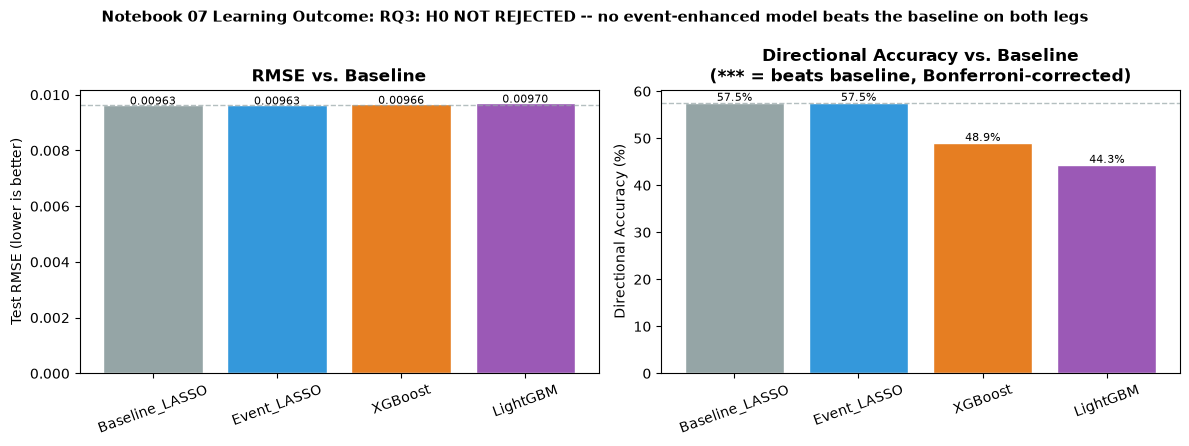

✓ Saved reports/figures/07_learning_outcome.png
  All three event-enhanced models sit close to the baseline's dashed reference line on both metrics --
  visually, this is what 'null result, honestly reported' looks like: real differences, none large or
  consistent enough to clear the pre-registered significance bar.


In [30]:
import matplotlib.pyplot as plt

model_names = ['Baseline_LASSO', 'Event_LASSO', 'XGBoost', 'LightGBM']
all_metrics = {
    'Baseline_LASSO': metrics_test_baseline,
    'Event_LASSO': metrics_test_el,
    'XGBoost': metrics_test_xgb,
    'LightGBM': metrics_test_lgb,
}
colors = ['#95a5a6', '#3498db', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: RMSE (lower is better) -- baseline drawn as a reference line
ax = axes[0]
rmses = [all_metrics[m]['RMSE'] for m in model_names]
bars = ax.bar(model_names, rmses, color=colors, edgecolor='white')
ax.axhline(rmses[0], color='#95a5a6', linewidth=1, linestyle='--', alpha=0.7)
for b, v in zip(bars, rmses):
    ax.text(b.get_x() + b.get_width()/2, v + 0.00002, f'{v:.5f}', ha='center', fontsize=8)
ax.set_ylabel('Test RMSE (lower is better)')
ax.set_title('RMSE vs. Baseline', fontweight='bold')
ax.tick_params(axis='x', rotation=20)

# Panel 2: Directional accuracy, with the Bonferroni-corrected verdict marked
ax2 = axes[1]
dir_accs = [all_metrics[m]['Dir_Acc'] * 100 for m in model_names]
bars2 = ax2.bar(model_names, dir_accs, color=colors, edgecolor='white')
ax2.axhline(dir_accs[0], color='#95a5a6', linewidth=1, linestyle='--', alpha=0.7)
for i, (name, b, v) in enumerate(zip(model_names, bars2, dir_accs)):
    marker = ''
    if name in comparison_results:
        marker = ' ***' if 'Beats baseline' in comparison_results[name]['bonferroni_verdict']['verdict'] else ''
    ax2.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%{marker}', ha='center', fontsize=8)
ax2.set_ylabel('Directional Accuracy (%)')
ax2.set_title('Directional Accuracy vs. Baseline\n(*** = beats baseline, Bonferroni-corrected)', fontweight='bold')
ax2.tick_params(axis='x', rotation=20)

verdict_text = 'RQ3: H0 NOT REJECTED -- no event-enhanced model beats the baseline on both legs' if not any_beats else 'RQ3: SUPPORTED'
fig.suptitle(f'Notebook 07 Learning Outcome: {verdict_text}', fontsize=11, fontweight='bold')
plt.tight_layout()
fig_path = REPORTS / 'figures'
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / '07_learning_outcome.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved reports/figures/07_learning_outcome.png")
print(f"  All three event-enhanced models sit close to the baseline's dashed reference line on both metrics --")
print(f"  visually, this is what 'null result, honestly reported' looks like: real differences, none large or")
print(f"  consistent enough to clear the pre-registered significance bar.")

---
## Section 9 — Save, Hash, Reload, and Freeze FES v1.1 Outputs

In [31]:
core_keys = ('RMSE', 'MAE', 'R2', 'Dir_Acc', 'IC')
model_comparison_full = pd.DataFrame([
    {'Model': 'Baseline_LASSO', 'Split': 'train', **{k: v for k, v in compute_metrics(y_train, pred_train_baseline).items() if k in core_keys}},
    {'Model': 'Baseline_LASSO', 'Split': 'test', **{k: v for k, v in metrics_test_baseline.items() if k in core_keys}},
    {'Model': 'Event_LASSO', 'Split': 'train', **{k: v for k, v in metrics_train_el.items() if k in core_keys}},
    {'Model': 'Event_LASSO', 'Split': 'test', **{k: v for k, v in metrics_test_el.items() if k in core_keys}},
    {'Model': 'XGBoost', 'Split': 'train', **{k: v for k, v in metrics_train_xgb.items() if k in core_keys}},
    {'Model': 'XGBoost', 'Split': 'test', **{k: v for k, v in metrics_test_xgb.items() if k in core_keys}},
    {'Model': 'LightGBM', 'Split': 'train', **{k: v for k, v in metrics_train_lgb.items() if k in core_keys}},
    {'Model': 'LightGBM', 'Split': 'test', **{k: v for k, v in metrics_test_lgb.items() if k in core_keys}},
])

train_predictions = {'Event_LASSO': pred_train_el, 'XGBoost': pred_train_xgb, 'LightGBM': pred_train_lgb}
test_predictions = {'Event_LASSO': pred_test_el, 'XGBoost': pred_test_xgb, 'LightGBM': pred_test_lgb}
model_diagnostics = {}
for name in candidates:
    test_pred = test_predictions[name]; train_pred = train_predictions[name]
    correct = int(np.sum(np.sign(test_pred) == np.sign(y_test)))
    model_diagnostics[name] = {
        'residual_diagnostics_test': residual_diagnostics(y_test, test_pred),
        'prediction_intervals': empirical_prediction_intervals(y_train, train_pred),
        'rmse_bootstrap_ci_test': block_bootstrap_rmse_ci(y_test, test_pred),
        'dir_acc_binomial_ci_test': wilson_interval(correct, len(y_test)),
    }

rq3_supported = bool(any(res['bonferroni_verdict']['rmse_leg_significant'] and
                         res['bonferroni_verdict']['dir_acc_leg_significant']
                         for res in comparison_results.values()))
rq3_verdict = 'SUPPORTED' if rq3_supported else 'H0(3) NOT REJECTED'
model_metadata_out = {
    'model_suite_version': '1.1', 'model_contract_version': 'MCP v1.0',
    'feature_matrix_version': 'FES v1.1', 'feature_matrix_sha256': matrix_sha256,
    'random_seed': RANDOM_SEED, 'train_rows': len(train), 'test_rows': len(test),
    'n_features': len(ALL_FEATURES), 'features': ALL_FEATURES,
    'models': {
        'Event_LASSO': {'alpha_selected': float(event_lasso.alpha_),
                        'nonzero_coefficients': int(np.sum(event_lasso.coef_ != 0)),
                        'tuning': 'LassoCV TimeSeriesSplit(5)'},
        'XGBoost': {'best_params': xgb_params, 'parameter_source': tree_parameter_source},
        'LightGBM': {'best_params': lgb_params, 'parameter_source': tree_parameter_source},
        'Random_Forest_RQ2': {'n_estimators': 500, 'random_state': RANDOM_SEED,
                              'role': 'importance only; not an RQ3 candidate'},
    },
    'libraries': {'python': sys.version, 'platform': platform.platform(),
                  'scikit_learn': package_version('scikit-learn'),
                  'xgboost': package_version('xgboost'), 'lightgbm': package_version('lightgbm')},
}
statistical_tests_out = {
    'model_suite_version': '1.1', 'feature_matrix_version': 'FES v1.1',
    'feature_matrix_sha256': matrix_sha256, 'baseline_model_version': 'Baseline_LASSO v1.1',
    'alpha_bonferroni': ALPHA_BONFERRONI, 'family_size': 3,
    'correction': 'Bonferroni (statistical_decision_matrix.md Part K)',
    'rq3_verdict': rq3_verdict,
    'results_by_model': {
        name: {'train': {k: v for k, v in compute_metrics(y_train, train_predictions[name]).items()},
               'test': {k: v for k, v in metrics.items()},
               **model_diagnostics[name], 'comparison_vs_baseline': comparison_results[name]}
        for name, (_, metrics) in candidates.items()
    },
}
model_validation = {
    'validation_status': 'PASS', 'model_suite_version': '1.1',
    'feature_matrix_version': 'FES v1.1', 'feature_matrix_sha256': matrix_sha256,
    'feature_matrix_validation_status': fm_validation['validation_status'],
    'baseline_model_version': 'Baseline_LASSO v1.1',
    'baseline_validation_status': baseline_validation['validation_status'],
    'feature_count': len(ALL_FEATURES), 'train_rows': len(train), 'test_rows': len(test),
    'finite_scaled_inputs': True,
    'shap_reconstruction_max_abs_diff': {
        'Event_LASSO': float(_diff_el), 'XGBoost': float(_diff_xgb), 'LightGBM': float(_diff_lgb)},
    'random_forest_rq2': {
        'ranking_rows': len(feature_importance),
        'importance_sum': float(feature_importance['importance'].sum()),
        'selected_gt_0_001': int(feature_importance['selected'].sum()),
        'top_decile_n': top_decile_n, 'top_decile_contains_event': rq2_top_decile_event,
        'top_decile_contains_macro': rq2_top_decile_macro,
    },
    'rq3_verdict': rq3_verdict, 'historical_comparison': historical_comparison,
}

event_lasso_path = MODELS / 'event' / 'event_lasso.joblib'
xgboost_path = MODELS / 'event' / 'xgboost.joblib'
lightgbm_path = MODELS / 'event' / 'lightgbm.joblib'
rf_path = MODELS / 'event' / 'random_forest_importance_tool.joblib'
metadata_path = MODELS / 'event' / 'event_model_metadata.json'
comparison_path = REPORTS / 'model_comparison' / 'model_comparison.parquet'
statistics_path = REPORTS / 'model_comparison' / 'statistical_tests.json'
predictions_path = REPORTS / 'model_comparison' / 'event_model_predictions.parquet'
importance_path = REPORTS / 'model_comparison' / 'feature_importance.parquet'
shap_el_path = REPORTS / 'model_comparison' / 'shap_values_event_lasso.parquet'
shap_xgb_path = REPORTS / 'model_comparison' / 'shap_values_xgboost.parquet'
shap_lgb_path = REPORTS / 'model_comparison' / 'shap_values_lightgbm.parquet'
shap_summary_path = REPORTS / 'model_comparison' / 'shap_importance_summary.parquet'
validation_path = REPORTS / 'model_comparison' / 'model_evaluation_validation.json'

joblib.dump(event_lasso, event_lasso_path); joblib.dump(xgb_model, xgboost_path)
joblib.dump(lgb_model, lightgbm_path); joblib.dump(rf_importance_model, rf_path)
metadata_path.write_text(json.dumps(model_metadata_out, indent=2, default=str))
model_comparison_full.to_parquet(comparison_path, index=False)
statistics_path.write_text(json.dumps(statistical_tests_out, indent=2, default=str, allow_nan=False))
event_model_predictions.to_parquet(predictions_path, index=False)
feature_importance.to_parquet(importance_path, index=False)
shap_event_lasso.to_parquet(shap_el_path, index=False)
shap_xgboost.to_parquet(shap_xgb_path, index=False)
shap_lightgbm.to_parquet(shap_lgb_path, index=False)
shap_importance_summary.to_parquet(shap_summary_path, index=False)
validation_path.write_text(json.dumps(model_validation, indent=2, default=str, allow_nan=False))

artifact_paths = {
    'event_lasso_model': event_lasso_path, 'xgboost_model': xgboost_path,
    'lightgbm_model': lightgbm_path, 'random_forest_model': rf_path,
    'metadata': metadata_path, 'model_comparison': comparison_path,
    'statistical_tests': statistics_path, 'predictions': predictions_path,
    'feature_importance': importance_path, 'shap_event_lasso': shap_el_path,
    'shap_xgboost': shap_xgb_path, 'shap_lightgbm': shap_lgb_path,
    'shap_importance_summary': shap_summary_path,
}
model_validation['artifact_sha256'] = {
    name: hashlib.sha256(path.read_bytes()).hexdigest() for name, path in artifact_paths.items()}
validation_path.write_text(json.dumps(model_validation, indent=2, default=str, allow_nan=False))
print(f'✓ Wrote {len(artifact_paths) + 1} validated FES v1.1 artefacts.')

✓ Wrote 14 validated FES v1.1 artefacts.


In [32]:
saved_validation = json.loads(validation_path.read_text())
saved_metadata = json.loads(metadata_path.read_text())
saved_statistics = json.loads(statistics_path.read_text())
saved_comparison = pd.read_parquet(comparison_path)
saved_predictions = pd.read_parquet(predictions_path)
saved_importance = pd.read_parquet(importance_path)
saved_shap_el = pd.read_parquet(shap_el_path)
saved_shap_xgb = pd.read_parquet(shap_xgb_path)
saved_shap_lgb = pd.read_parquet(shap_lgb_path)
saved_shap_summary = pd.read_parquet(shap_summary_path)

assert saved_validation['validation_status'] == 'PASS'
assert saved_validation['feature_matrix_sha256'] == matrix_sha256
assert saved_validation['artifact_sha256'] == {
    name: hashlib.sha256(path.read_bytes()).hexdigest() for name, path in artifact_paths.items()}
assert saved_metadata['model_suite_version'] == '1.1' and saved_metadata['n_features'] == 92
assert saved_metadata['feature_matrix_sha256'] == matrix_sha256
assert saved_statistics['feature_matrix_version'] == 'FES v1.1'
assert saved_statistics['rq3_verdict'] == rq3_verdict
assert saved_comparison.shape == (8, 7)
assert len(saved_predictions) == len(fm)
assert saved_predictions[['date', 'split']].reset_index(drop=True).equals(
    fm[['date', 'split']].reset_index(drop=True))
assert len(saved_importance) == len(saved_shap_summary) == 92
assert np.isclose(saved_importance['importance'].sum(), 1.0)
assert saved_importance['feature'].is_unique and set(saved_importance['feature']) == set(ALL_FEATURES)
for saved_shap in [saved_shap_el, saved_shap_xgb, saved_shap_lgb]:
    assert saved_shap.shape == (len(test), len(ALL_FEATURES) + 1)
    assert set(saved_shap.columns) == set(ALL_FEATURES) | {'base_value'}

reloaded_el = joblib.load(event_lasso_path); reloaded_xgb = joblib.load(xgboost_path)
reloaded_lgb = joblib.load(lightgbm_path); reloaded_rf = joblib.load(rf_path)
assert np.allclose(reloaded_el.predict(X_test), pred_test_el, atol=0, rtol=0)
assert np.allclose(reloaded_xgb.predict(X_test), pred_test_xgb)
assert np.allclose(reloaded_lgb.predict(X_test), pred_test_lgb)
assert np.allclose(reloaded_rf.feature_importances_, saved_importance.set_index('feature').loc[ALL_FEATURES, 'importance'])
print(f'✓ Saved-artifact verification: PASS ({len(artifact_paths) + 1}/{len(artifact_paths) + 1} files reloaded/checked).')
for name, digest in saved_validation['artifact_sha256'].items():
    print(f'  {name:<24}: {digest}')

✓ Saved-artifact verification: PASS (14/14 files reloaded/checked).
  event_lasso_model       : 750dbd5e4fedfcd9d95ba71cd3d32ab4404d631e9c0a1f164b7c1c085cade207
  xgboost_model           : f1e62268e10b33f8374f7a7536c836a82b2904fccfb41360f012cbd420159c7c
  lightgbm_model          : 7ced6ffa417e4250062d984d7eba8fcd712d3a7b6c811034c4ec5b2e3ad46d23
  random_forest_model     : eac8a8ef3bf1611000d06d717dac9da659449e3e25100033fdd381586154d16b
  metadata                : 11b55297bc87ed80ae83994f26fb340c259ed7deaabcd967c73e1b586e2e4e23
  model_comparison        : a63e57209a5215432d5d623b4ea573d72826cb7ec8e46604150b958b92ab7cb6
  statistical_tests       : 0bdb68cce38cd961d672a141b4f9dc63d62a806338e185721306633cf57b3afd
  predictions             : 6e6130c79248e3cdc552d8b053b0cc380b503445d061ec97d3c4442e348541d1
  feature_importance      : ecd2edda99c9675447bec37c7291c1e9323c1d9a4f835fbbca64f38bcbf7de2e
  shap_event_lasso        : db01bb65112d91304997f251278aca89f2bdcf3f269266eb9af83ee8f1aaba01
  

In [33]:
print('=' * 65)
print('PHASE 7 — FES v1.1 MODEL EVALUATION: SUMMARY')
print('=' * 65)
print(f'\nTEST-SPLIT METRICS')
print(f'  {"Model":<15}{"RMSE":>10}{"Dir_Acc":>10}')
print(f'  {"Baseline_LASSO":<15}{metrics_test_baseline["RMSE"]:>10.6f}{metrics_test_baseline["Dir_Acc"]:>10.3f}')
for name, (pred, m) in candidates.items():
    print(f'  {name:<15}{m["RMSE"]:>10.6f}{m["Dir_Acc"]:>10.3f}')
print(f'\nRQ2 TOP-DECILE: event={rq2_top_decile_event}; macro={rq2_top_decile_macro}')
print(f'RQ3 VERDICT: {rq3_verdict}')
print(f'VALIDATION: {saved_validation["validation_status"]}')
print(f'\nOUTPUTS -> models/event/, reports/model_comparison/')
print(f'\nNEXT: Notebook 08 — Results Visualisation')
print('=' * 65)

PHASE 7 — FES v1.1 MODEL EVALUATION: SUMMARY

TEST-SPLIT METRICS
  Model                RMSE   Dir_Acc
  Baseline_LASSO   0.009631     0.575
  Event_LASSO      0.009631     0.575
  XGBoost          0.009656     0.489
  LightGBM         0.009700     0.443

RQ2 TOP-DECILE: event=False; macro=True
RQ3 VERDICT: H0(3) NOT REJECTED
VALIDATION: PASS

OUTPUTS -> models/event/, reports/model_comparison/

NEXT: Notebook 08 — Results Visualisation


## Section Summary & Handoff to Notebook 08

Notebook 07 retrains and validates the three event-enhanced candidates on all 92 FES v1.1 features, compares them with `Baseline_LASSO` v1.1 under the unchanged Bonferroni two-leg rule, regenerates exact held-out SHAP contributions, and restores the reproducible 500-tree Random Forest importance step for RQ2. The dated FES v1.0 files remain archived and every current delta is recorded. Notebook 08 must now refresh its RQ2/RQ3 figures exclusively from these validated FES v1.1 outputs.